# Project Name   - Shopping Trends EDA

### GitHub Link - 
https://github.com/Naik-Prathamesh/Exploratory-Data-Analysis/tree/main/Shopping%20Trends%20EDA

# 1. Problem Statement
Retail businesses generate large volumes of customer transaction data, but without structured analysis, this data does not translate into actionable insights. The organisation lacks clarity on how customer demographics, purchasing behaviour, product categories, seasons, and subscription status influence spending patterns. This limits the ability to optimise marketing strategies, inventory planning, customer retention initiatives, and revenue growth.

The key challenge is to systematically analyze shopping trend data to identify meaningful patterns, relationships, and drivers of customer purchases. Understanding these factors is essential for making data-driven business decisions and improving overall business performance.


# 2. Business Objectives
1. **Understand Customer Demographics** - Analyse how demographic factors such as age and gender are distributed across the customer base and assess whether these factors influence purchase behaviour or spending levels.

2. **Analyse Purchasing Behaviour** - Evaluate purchase amount distributions to understand typical spending ranges variability and consistency in customer transactions.

3. **Identify High Performing Product Categories** - Determine which product categories contribute the most to purchases and revenue and examine differences in spending across categories.

4. **Evaluate Seasonal Impact on Sales** - Assess how seasons affect total and average purchase amounts across product categories to support seasonal inventory planning and promotional strategies.

5. **Measure the Impact of Subscription Status** - Compare purchase behaviour between subscribers and non-subscribers to understand whether subscriptions drive higher spending and customer value.

6. **Assess Customer Loyalty Indicators** - Analyse the relationship between previous purchases, review ratings and purchase amounts to identify indicators of repeat purchasing behaviour.

7. **Identify Relationships Between Key Variables** - Use correlation and multivariate analysis to detect relationships among numerical variables such as age, purchase amount, review rating and previous purchases.

8. **Support Data-Driven Decision Making** - Translate analytical insights into actionable recommendations that can improve marketing effectiveness, customer retention and revenue optimisation.


# 3. Data Understanding and Preparation


### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Filter warnings

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [4]:
df=pd.read_csv("/Users/prathameshnaik/Python/EDA/shopping_trends.csv")

### Dataset First View

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### Dataset Rows & Columns count

In [6]:
df.shape

(3900, 19)

### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

### Count Missing Values

In [8]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

### Count Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(0)

### Variables Description

In [10]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


### Dataset Columns

In [11]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

### Check Unique Values for each column

In [12]:

for column in df.columns:
    print(f'{column} : {len(df[column].unique())}')

Customer ID : 3900
Age : 53
Gender : 2
Item Purchased : 25
Category : 4
Purchase Amount (USD) : 81
Location : 50
Size : 4
Color : 25
Season : 4
Review Rating : 26
Subscription Status : 2
Payment Method : 6
Shipping Type : 6
Discount Applied : 2
Promo Code Used : 2
Previous Purchases : 50
Preferred Payment Method : 6
Frequency of Purchases : 7


### What did you know about your dataset?

The dataset consists of 3900 customer shopping records with 19 columns capturing demographic, transactional, and behavioral attributes. It represents individual customer purchases and related characteristics, enabling analysis of shopping patterns and spending behavior. Key features include:

- **Demographic Information**: Age, Gender
- **Transaction Details**: Purchase Amount (USD), Product Category, Season
- **Customer Behavior**: Subscription Status, Previous Purchases
- **Customer Feedback**: Review Rating
- **Payment Information**: Payment Method
- **Identifier Variable**: Customer ID

The dataset is a structured tabular dataset containing both numerical and categorical variables. It is designed for exploratory data analysis to understand customer preferences, seasonal trends, category-level performance, and the impact of subscriptions on purchasing behavior.

# 4. Exploratory Data Analysis 

## 1. Univariate Analysis

### 1.1. Gender Distribution
##### Insight -
**The chart shows customer gender distribution. Male customers significantly outnumber female customers. The dataset is gender-imbalanced, with male customers forming the majority of shopping activity.**

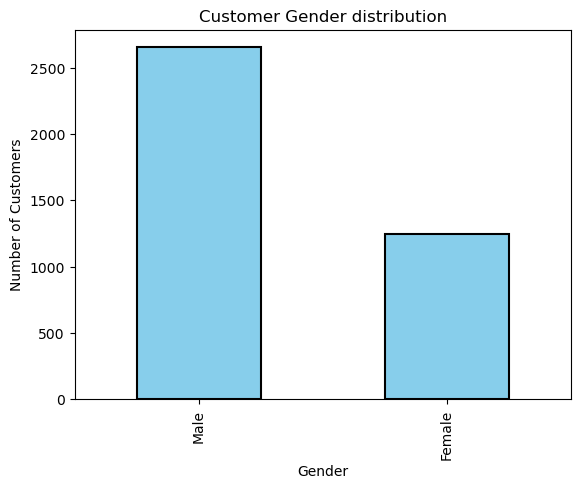

In [13]:
df['Gender'].value_counts().plot(kind='bar',color="skyblue",edgecolor="black",linewidth=1.5)
plt.title('Customer Gender distribution')
plt.ylabel('Number of Customers')
plt.show()

### 1.2. Subscription Status Distribution
##### Insight -
**The pie chart shows subscription status distribution. Most customers do not have a subscription. Approximately 73% are non-subscribers, while 27% are subscribers. Subscriptions represent a minority segment of the customer base.**

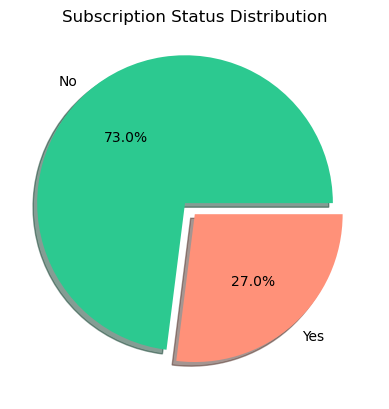

In [62]:
colors=['#2CC990','#FF9179']
df['Subscription Status'].value_counts().plot(kind='pie',autopct="%1.1f%%",colors=colors,explode=[0.1, 0],shadow=True)
plt.ylabel('')
plt.title('Subscription Status Distribution')
plt.show()

###  1.3. Purchase Amount Distribution
##### Insight -
**The histogram shows the distribution of purchase amounts. Purchase values are spread fairly evenly between low and high amounts, with no strong skew or extreme concentration. This indicates consistent spending behavior across customers rather than dominance of a specific price range.**

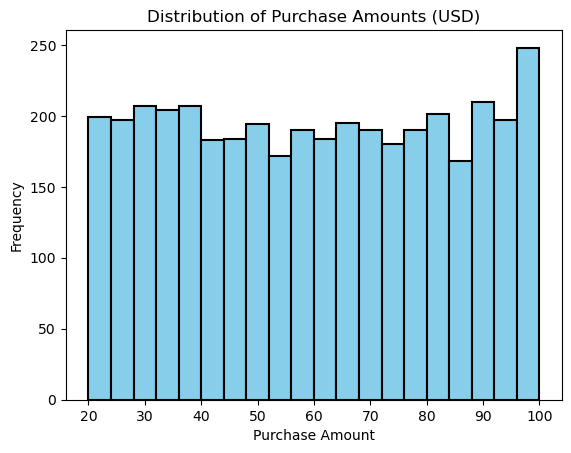

In [15]:
plt.hist(df["Purchase Amount (USD)"], bins=20,color="skyblue",edgecolor="black",linewidth=1.5)
plt.title('Distribution of Purchase Amounts (USD)')
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

### 1.4. Product Category Distribution
##### Insight - 
**The pie chart shows the distribution of purchases across product categories. Clothing accounts for the largest share of purchases, followed by Accessories. Footwear has a moderate share, while Outerwear contributes the smallest portion. Customer demand is concentrated mainly in Clothing and Accessories.**

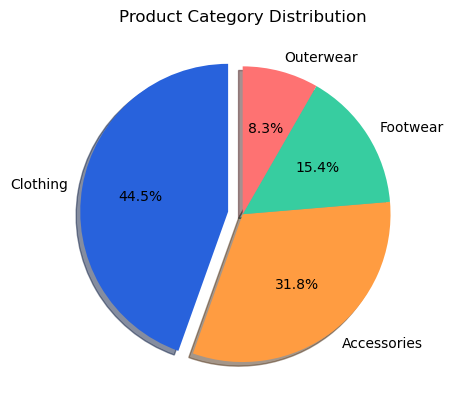

In [74]:
colors=['#2862DC','#FF9C41','#37CDA0','#FE7272']
df['Category'].value_counts().plot(kind='pie',autopct="%1.1f%%", startangle=90,colors=colors,
    explode=[0.1, 0, 0, 0],
    shadow=True)
plt.ylabel('')
plt.title('Product Category Distribution')
plt.show()

### 1.5. Payment Method Usage Count
##### Insight -
**The chart shows the count of transactions by payment method. Credit Card has the highest usage, but differences across methods are small. Payment preferences are broadly balanced, indicating no dominant payment channel.**

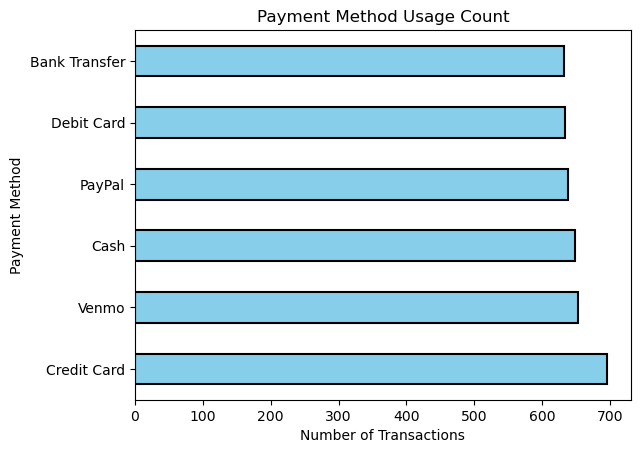

In [27]:
df["Payment Method"].value_counts().plot(kind="barh",color="skyblue",edgecolor="black",linewidth=1.5 )
plt.title('Payment Method Usage Count')
plt.xlabel('Number of Transactions')
plt.show()

## 2. Bivariate Analysis

### 2.1. Total Purchase Amount by Gender
##### Insight -
**The chart shows the total purchase amount (sum) by gender. Male customers contribute a significantly higher total purchase value than female customers. This difference reflects higher transaction volume and higher cumulative spending by male customers.**

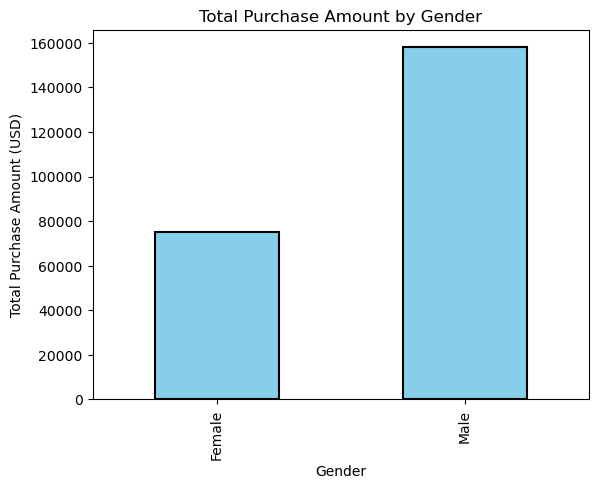

In [28]:

df.groupby("Gender")["Purchase Amount (USD)"].sum().plot(kind="bar",color="skyblue",edgecolor="black",linewidth=1.5)
plt.title('Total Purchase Amount by Gender')
plt.xlabel("Gender")
plt.ylabel("Total Purchase Amount (USD)")
plt.show()


### 2.2. Purchase Amount Distribution by Category

##### Insight -
**The boxplot shows the distribution of purchase amounts across product categories. Clothing, Footwear, and Accessories have similar median purchase values around the mid-range. Outerwear shows a slightly lower median but comparable spread. All categories exhibit a wide range of spending, indicating variability in customer purchase amounts within each category.**

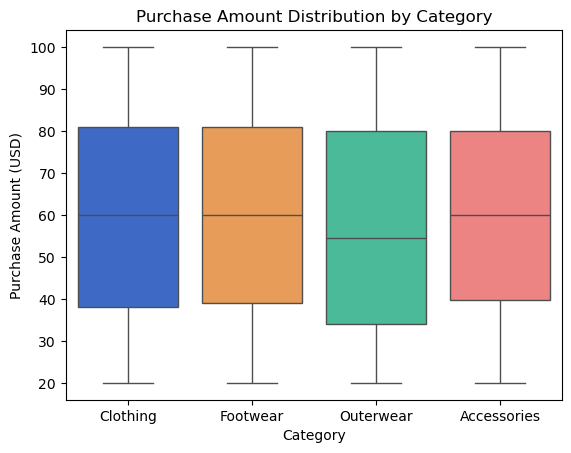

In [95]:
custom_palette=['#2862DC','#FF9C41','#37CDA0','#FE7272']
ax = sns.boxplot(
    y="Purchase Amount (USD)",
    x="Category",
    data=df,
    palette=custom_palette
)
ax.set_title("Purchase Amount Distribution by Category")
ax.set_ylabel("Purchase Amount (USD)")
plt.show()

### 2.3. Purchase Amount Trend by Age
##### Insight -
**The line plot shows the average purchase amount across age (with confidence interval smoothing). Purchase amounts remain relatively stable across ages, with minor fluctuations. There is no strong upward or downward trend, indicating age has little influence on purchase amount.**

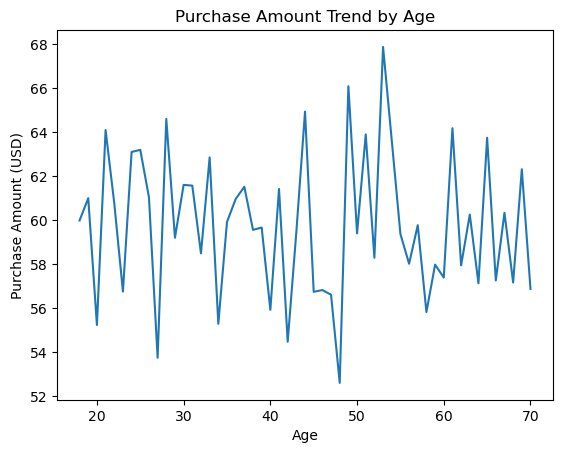

In [42]:
sns.lineplot(x="Age", y="Purchase Amount (USD)",data=df,ci=None )
plt.title('Purchase Amount Trend by Age')
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.show()

### 2.4. Purchase Amount by Season
##### Insight -
**The chart shows total purchase amount aggregated by season. Fall and Winter generate the highest total sales, Spring is slightly lower, and Summer records the lowest total purchase amount. This indicates clear seasonal variation in customer spending.**

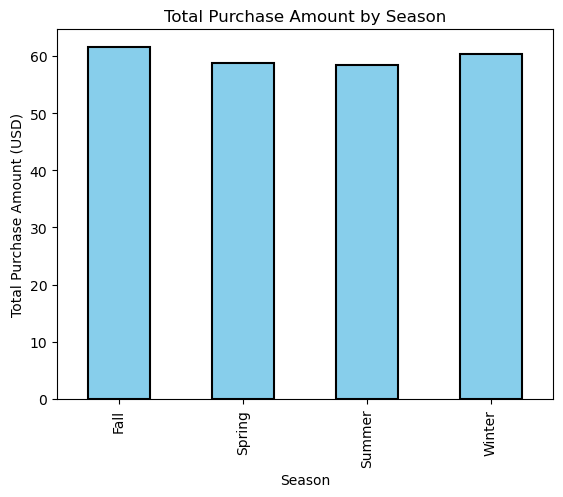

In [21]:
df.groupby('Season')['Purchase Amount (USD)'].mean().plot(kind='bar',color="skyblue",edgecolor="black",linewidth=1.5)
plt.title('Total Purchase Amount by Season')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

### 2.5. Purchase Amount Distribution by Age Group
##### Insight -
**The boxplot shows the distribution of purchase amounts across different age groups. Median spending is fairly consistent across all age ranges, with slightly higher median values in the younger age groups (<18 and 18–30). All age groups display a wide spread in purchase amounts, indicating similar variability in spending behavior regardless of age.**

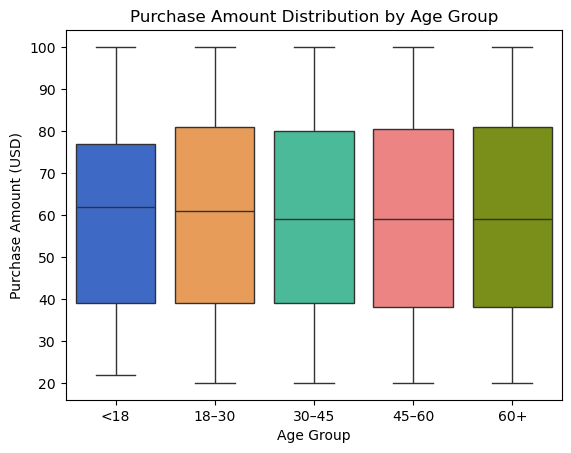

In [103]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["<18", "18–30", "30–45", "45–60", "60+"]
)
custom_palette=['#2862DC','#FF9C41','#37CDA0','#FE7272','#86A305']
ax = sns.boxplot(
    y="Purchase Amount (USD)",
    x="AgeGroup",
    data=df,
    palette=custom_palette
)

ax.set_title("Purchase Amount Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Purchase Amount (USD)")
plt.suptitle("")   
plt.show()

## 3. Multivariate Analysis

### 3.1. Correlation Analysis
##### Insight -
**The heatmap shows the correlation matrix between numerical variables. All correlations are very close to zero, indicating no strong linear relationship between age, purchase amount, review rating, and previous purchases. Customer ID has no meaningful relationship with any variable and is purely an identifier.**

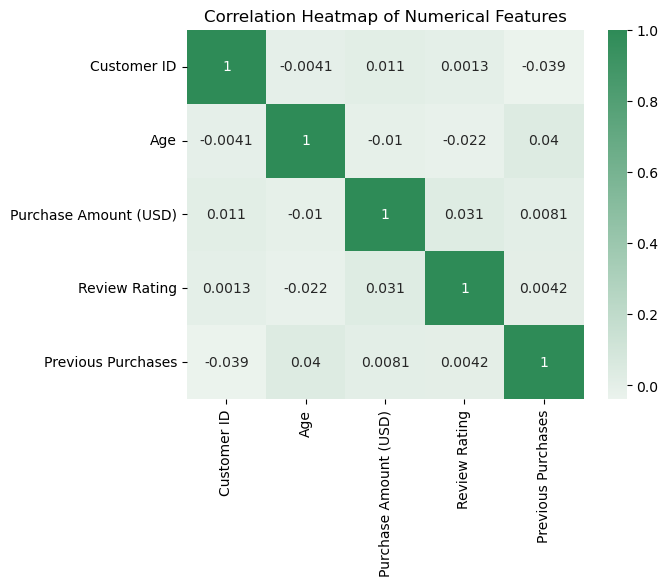

In [55]:
num_df = df.select_dtypes(include="number")
cmap = sns.light_palette("seagreen", as_cmap=True)

sns.heatmap(num_df.corr(), annot=True,cmap=cmap)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 3.2. Purchase Amount by Category and Season
##### Insight -
**The chart compares average purchase amount across product categories for each season.
Footwear and Accessories show slightly higher average spending overall. Fall generally records the highest average purchase amounts across most categories, while Summer tends to be lower, especially for Clothing and Outerwear. This indicates clear season–category interaction effects on customer spending.**

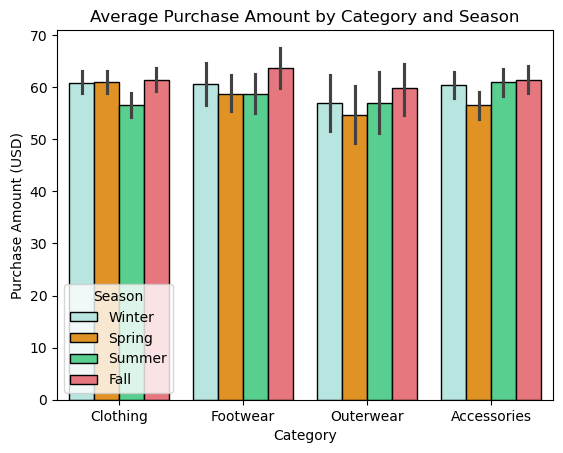

In [70]:
custom_palette=['#B2ECE7','#FF9705','#45E18D','#F8656E']
sns.barplot(
    x="Category",
    y="Purchase Amount (USD)",
    hue="Season",
    data=df,
    palette=custom_palette,
    estimator="mean",
    edgecolor="black",
    linewidth=1
)
plt.title("Average Purchase Amount by Category and Season")
plt.show()

### 3.3. Heatmap: Category vs Season
##### Insight -
**The heatmap shows the average purchase amount across product categories and seasons.
Footwear in Fall has the highest average spending, while Outerwear in Spring shows the lowest. Clothing and Accessories remain relatively stable across seasons, indicating consistent customer spending. Seasonal effects are strongest for Footwear and Outerwear.**

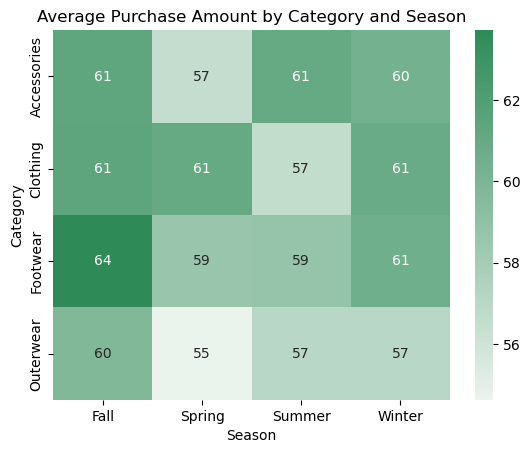

In [67]:
cmap = sns.light_palette("seagreen", as_cmap=True)
pivot = df.pivot_table(
    values="Purchase Amount (USD)",
    index="Category",
    columns="Season",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap=cmap)
plt.title("Average Purchase Amount by Category and Season")
plt.show()

### 3.4 Purchase Amount Distribution by Category and Subscription Status
##### Insight -
**The violin plot shows the distribution of purchase amounts by product category, split by subscription status.
Across all categories, subscribers tend to have slightly higher median purchase amounts and a denser distribution at higher values compared to non-subscribers. The overall spread is similar, indicating subscriptions influence spending level more than variability.**

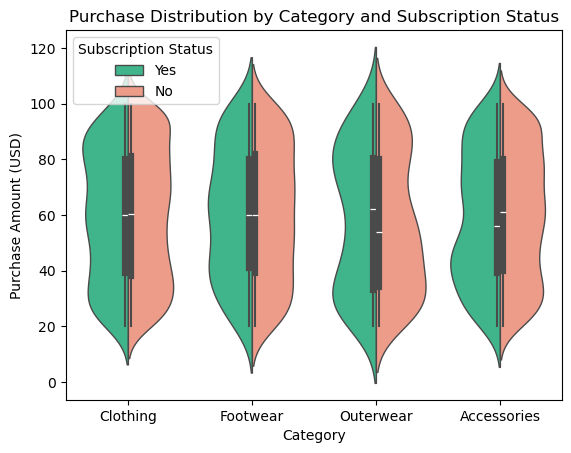

In [105]:
custom_palette = {
    "Yes": "#2CC990",
    "No":  "#FF9179"
}

ax = sns.violinplot(
    x="Category",
    y="Purchase Amount (USD)",
    hue="Subscription Status",
    data=df,
    split=True,
    palette=custom_palette,
    linewidth=1
)

ax.set_title("Purchase Distribution by Category and Subscription Status")
plt.show()

# 5. Business Recommendations
1.	**Leverage Seasonal Demand Patterns** -
Charts showing total and average purchase amounts by season indicate higher spending during Fall and Winter. Inventory stocking, promotions, and marketing campaigns should be concentrated in these seasons to maximize revenue impact.

2.	**Prioritize High-Performing Categories** -
Category distribution, boxplots, and season–category charts show Clothing, Accessories, and Footwear as the strongest contributors. Business focus should remain on these categories, with special emphasis on Footwear during Fall where average purchase amounts peak.

4.	**Expand and Promote Subscription Programs** -
Violin plots comparing subscribers and non-subscribers show subscribers consistently spending slightly more across categories. Subscription programs should be strengthened and actively promoted to increase customer lifetime value.

6.	**Use Behavior-Based Targeting Over Demographics** -
Charts comparing purchase amount by age and gender show minimal differences in average spending. Marketing strategies should shift away from demographic targeting and focus on behavioral indicators such as subscription status and purchase history.


8.	**Plan Category-Specific Seasonal Campaigns** -
Multivariate charts (grouped bars and heatmaps) show that seasonal impact varies by category. Promotions should be tailored at the category–season level rather than applying uniform discounts across all products.


10.	**Maintain Flexible Payment Options** -
Payment method distribution charts show near-equal usage across methods. All payment options should be maintained to avoid restricting customer choice or reducing conversions.


12.	**Avoid Overreliance on Correlated Metrics** -
The correlation heatmap shows weak relationships among numerical variables. Business decisions should rely on observed behavioral patterns and aggregated trends rather than assuming direct linear relationships.

# 6. Conclusion
The exploratory data analysis of the shopping trends dataset highlights key insights into customer behaviour and purchasing patterns. While demographics such as age and gender have minimal impact on individual purchases, product category and season significantly influence spending. Clothing and Accessories are the leading transaction categories, with Footwear performing particularly well in Fall. Seasonal variations show higher sales in Fall and Winter compared to Spring and Summer, underscoring the need for strategic inventory and marketing planning. Subscription status also plays a crucial role, with subscribers making slightly higher purchases, indicating the potential for enhancing subscription programs to boost customer retention and lifetime value. The analysis reveals weak linear relationships among numerical variables, suggesting that spending is affected by multiple factors. Payment methods are evenly distributed, reflecting diverse customer preferences. Overall, the dataset offers valuable insights for data-driven decision-making, emphasising the importance of behavioural and seasonal factors over demographics to optimise marketing, inventory, and subscription strategies for sustainable business growth.